In [1]:
import numpy as np
from scipy.integrate import odeint
from pysindy.feature_library import PolynomialLibrary
import matplotlib.pyplot as plt
import pysindy as ps
#from scipy.optimize import fsolve
from pysindy.differentiation import FiniteDifference
import pandas
from mpl_toolkits import mplot3d
#from scipy.optimize import curve_fit
from pysindy.feature_library import CustomLibrary
import math
import pandas as pd
import torch
import torch.optim as optim
from scipy.stats import norm

In [2]:
#!pip install pysindy==1.7.5 # I needed this to use colab. You do not need to run this

In [3]:
#!pip install scipy==1.10.1 # I needed this to use colab. You do not need to run this

In [4]:
#!pip install --force-reinstall numpy==1.26.1 #needed for colab. You do not need to run

In [5]:
#Original Lotka Volterra Model
def LV_model(z,t,pars):
    x = z[0]
    y = z[1]
    #The model
    alpha,beta,delta,gamma = pars
    dxdt = alpha*x-beta*x*y
    dydt = delta*x*y-gamma*y
    dzdt = [dxdt,dydt]
    return dzdt

In [6]:
#model of polynomial basis functions up to order 2
def SINDY_model(z,t,pars):
    #function dydt=toy_model(y,t,pars)
    x = z[0]
    y = z[1]
    #The model
    a0,a1,a2,a3,a4,a5,b0,b1,b2,b3,b4,b5 = pars
    dxdt = a0+a1*x+a2*y+a3*x*x+a4*x*y+a5*y*y
    dydt = b0+b1*x+b2*y+b3*x*x+b4*x*y+b5*y*y
    dzdt = [dxdt,dydt]
    return dzdt

In [7]:
#initialize parameters
pars = {}
#These parameters stay the same for all trajectories
alpha=0.5
gamma=0.5


num_init_cond = 1
# beta_values=np.random.normal(0.75,0.02,10)
# delta_values=np.random.normal(0.75,0.02,10)
# beta_values=[0.71416289,0.72645622,0.72112118,0.75779844,0.70492961,0.77965516,
#  0.75707882,0.73627916,0.73401775,0.75131397]
# delta_values=[0.77319161,0.7124301,0.72516869,0.77912128,0.75048612,0.77305671,
#  0.76371736,0.74538159,0.76385077,0.75557741]
beta_values=np.random.normal(0.75,0.3,10)
delta_values=np.random.normal(0.75,0.3,10)

# # # standard deviation of 0.01
# beta_values=[0.74828472,0.7491082, 0.73631697,0.75699745,0.75335083,0.74631238,
#  0.73586599, 0.75054504, 0.76091458, 0.73935457]
# delta_values=[0.73151347,0.75054292,0.73651186,0.74704779,0.73677807,0.74344501,
#  0.75263935,0.74214918,0.74999374,0.74511515]

#standard deviation of 0.02
beta_values=[0.72697085, 0.76631465, 0.77172031, 0.76041079, 0.74474558, 0.76002462,
 0.77700365, 0.75098167, 0.73512634, 0.76306792]
delta_values=[0.75243179, 0.76706174, 0.72149368, 0.70612509, 0.73274227, 0.74488728,
 0.74441558, 0.75196563, 0.7340742,  0.72855084]

# # #standard deviation of 0.05
# beta_values=[0.64781634, 0.76114864, 0.83235598, 0.69118393, 0.74096772, 0.75354608,
#  0.85364612, 0.81409049, 0.75279743, 0.74669214]
# delta_values=[0.66725014, 0.81723332, 0.73918777, 0.73512165, 0.76869111, 0.81514014,
#  0.6970145,  0.73448263, 0.7727234,  0.71265226]



# #standard deviation of 0.1
# beta_values=[0.75355398, 0.73634852, 0.87792276, 0.74288144, 0.85455609, 0.95223156,
#  0.6574785,  0.7811082,  0.73108048, 0.40068928]
# delta_values=[0.78189457, 0.66235211, 0.53135603, 0.77639703, 0.71322389, 0.81338018,
#  0.6831353,  0.59422923, 0.43783275, 0.63756668]

# ## SD of 0.2
# beta_values=[0.52703515, 0.5805379,  0.90890555, 0.56725778, 0.68743638, 0.76881931,
#  0.55959627, 0.68196212, 1.06846415, 0.40260489]
# delta_values=[0.9001515,  0.80233638, 0.70513287, 0.77683696, 0.61297934, 0.80971441,
#  0.47025168, 0.83917492, 0.68384131, 0.68776274]

# #SD of 0.3
# beta_values=[0.38006498, 1.35097834, 0.77624472, 0.88151443, 0.38500847, 0.3283898,
#  0.91009318, 0.5992619,  0.88156411, 0.72656794]
# delta_values=[0.62521158, 0.56993882, 0.52251072, 0.92022612, 0.83720046, 1.19547481,
#  0.39051612, 1.05367205, 0.6755216, 0.85538068]

print(beta_values)
print(delta_values)

#choose initial values from a uniform distribution
# x_init_values = np.random.uniform(1,3,num_init_cond)
# y_init_values = np.random.uniform(1,3,num_init_cond)
t = np.linspace(0, 10, 101)
print(t)

# t_test=np.linspace(0,10,20)

#Once chosen, fix the initial values to be the same for all iterations
x_init_values=[2]
y_init_values=[2]
# x_init_values=[2.90311835,2.08080383,1.92179248,2.54818293]
# y_init_values=[2.8146938,2.05761677,1.45111475,2.45620932]

# print(x_init_values)
# print(y_init_values)

[0.72697085, 0.76631465, 0.77172031, 0.76041079, 0.74474558, 0.76002462, 0.77700365, 0.75098167, 0.73512634, 0.76306792]
[0.75243179, 0.76706174, 0.72149368, 0.70612509, 0.73274227, 0.74488728, 0.74441558, 0.75196563, 0.7340742, 0.72855084]
[ 0.   0.1  0.2  0.3  0.4  0.5  0.6  0.7  0.8  0.9  1.   1.1  1.2  1.3
  1.4  1.5  1.6  1.7  1.8  1.9  2.   2.1  2.2  2.3  2.4  2.5  2.6  2.7
  2.8  2.9  3.   3.1  3.2  3.3  3.4  3.5  3.6  3.7  3.8  3.9  4.   4.1
  4.2  4.3  4.4  4.5  4.6  4.7  4.8  4.9  5.   5.1  5.2  5.3  5.4  5.5
  5.6  5.7  5.8  5.9  6.   6.1  6.2  6.3  6.4  6.5  6.6  6.7  6.8  6.9
  7.   7.1  7.2  7.3  7.4  7.5  7.6  7.7  7.8  7.9  8.   8.1  8.2  8.3
  8.4  8.5  8.6  8.7  8.8  8.9  9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7
  9.8  9.9 10. ]


In [8]:
# #generate an initial guess for the common components of beta and delta
# #generate trajectories for each combination of beta, delta, and initial conditions, recover beta and delta using SINDY
# #take the average of the recovered betas and deltas, this is our beta_c and delta_c, respectively
# MSE_values=[]
# RSE_values=[]

# recovered_beta=np.array([]) #array to store all beta values recovered by SinDY
# recovered_delta=np.array([]) #array to store all delta values recovered by SinDY
# for beta_value in beta_values: #iterate thru each combination of beta,delta,initial condition
#     for delta_value in delta_values:
#         for i in range(num_init_cond):
#             pars=[alpha,beta_value,delta_value,gamma] #set parameters as the true values
#             x_values=[]
#             y_values=[]
#             T=[]
#             x0=x_init_values[i]
#             y0=y_init_values[i]
#             z=odeint(LV_model,np.array([x0,y0]),t,args=(pars,)) #generate trajectory
#             x_values=np.append(x_values,z[:,0])
#             y_values=np.append(y_values,z[:,1])
#             T=np.append(T,t)
#             W = np.stack((x_values, y_values), axis=-1)
#             model = ps.SINDy(feature_names=["x", "y"]) #use SINDY to fit a model to the trajectory
#             model.fit(W, t=T)
#             model.print()

#             S=model.score(W, t=T)
#             C= model.coefficients()
#             #print(C)

#             beta_r=-C[0,4] #coefficient that corresponds to beta
#             delta_r=C[1,4] #coefficient that corresponds to delta
#             #print(C[0,4])
#             x_values_sindy=[]
#             y_values_sindy=[]
#             T=[]

#             recovered_pars=[alpha,beta_r,gamma,delta_r] #set the parameters to the recovered values
#             z_hat=odeint(LV_model,np.array([x0,y0]),t,args=(recovered_pars,)) #generate estimated trajectory with the parameters recovered from SINDy
#             x_values_sindy=np.append(x_values_sindy,z[:,0])
#             y_values_sindy=np.append(y_values_sindy,z[:,1])
#             T=np.append(T,t)

#             recovered_beta=np.append(recovered_beta, C[0,4]) #beta is the coefficient of xy in the equation for x'
#             recovered_delta=np.append(recovered_delta, C[1,4]) #delta is the coefficient of xy in the equation for y'
#             MSE = np.square(np.subtract(z,z_hat)).mean() #compare the original trajectory to the one generated using SINDy, this is the MSE generated by SINDy
#             RSE= MSE/np.linalg.norm(z) #Rel squared error
#             MSE_values=np.append(MSE_values,MSE)
#             RSE_values=np.append(RSE_values,RSE)


# print("The average MSE is", np.average(MSE_values)) #We store the MSE for each trajectory and then take the average
# print("The average RSE is", np.average(RSE_values)) #do the same for the RSE

# beta_c=-np.average(recovered_beta) #Our initial guess for the common components is the average of the parameter values recovered by sindy
# delta_c=np.average(recovered_delta)
# plt.show()
# print("beta c is", beta_c)
# print("delta c is", delta_c)

In [9]:
#the initial guess for the parameters
#we will update the parameter values using Adam
#We initialize the common components as the average beta/delta recovered by SINDy
#Initialize the personalize components as zero

init_guess_common=[0,0]
#init_guess_common=[beta_c,delta_c] #initialize the common component

#As there is a personalized component for each trajectory, the number of personalized components is (num trajectories*num parameters being personalized)
# There are len(beta_values)*len(delta_values)*num_init_cond total trajectories
#there are len(init_guess_common) parameters being personalized (beta and delta)
#Thus there are len(beta_values)*len(delta_values)*num_init_cond*len(init_guess_common) total personalized components
init_guess=np.zeros(len(init_guess_common)*len(beta_values)*len(delta_values)*num_init_cond)

#init_guess=np.concatenate((init_guess_common,init_guess_pers)) #put both common and pers comps into a single vector
init_guess=np.c_[init_guess] #make the correct shape

print(init_guess)
print(init_guess.shape)

init_guess=torch.tensor(init_guess, requires_grad=True) #convert to a tensor to use PyTorch

[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.

In [10]:
#Loss function for the training
#Takes in a tensor of parameter values as input
#Returns sum_{i=1}^{n} ||X_dot-Theta(X)(Eps_c+Eps_p)||_2^2+||Eps_c+Eps_p_i||_1+||Eps_p_i||_2 (the loss function)
def loss(init_guess):
  sum=0 #initialize sum
  L_1_sum=0
  L_2_sum=0
  L_3_sum=0
  count=0
  for i in range(len(beta_values)): #loop through each beta,delta, and init_cond to generate a trajectory
    for j in range(len(delta_values)):
      for k in range(num_init_cond):
            x0=x_init_values[k]
            y0=y_init_values[k]
            params=[alpha,beta_values[i],delta_values[j],gamma] #generate trajectories with true params
            results=odeint(LV_model,[x0,y0],t,args=(params,))
            results= np.array(results)
            W=np.c_[results]

            #separate the data into x and y values
            x_values=W[:,0] #x-values
            y_values=W[:,1] #y-values
            fd=FiniteDifference()
            W_prime=fd._differentiate(W,t) #Take the derivative using fd


            #convert everything into tensors
            x_values_tensor = torch.tensor(x_values, dtype=init_guess.dtype)
            y_values_tensor = torch.tensor(y_values, dtype=init_guess.dtype)
            W_prime_tensor = torch.tensor(W_prime, dtype=init_guess.dtype)


            #Estimate the derivatives
            #W_prime is the derivative using finite difference methods
            #W_prime_hat is the estimated derivative (the right hand side of ODE, with beta=beta_c+beta_p_(count) and delta=delta_c+delta_p_(count)

            W_prime=W_prime_tensor

            #Estimate the derivative using the RHS of the Lotka_Volterra eqns
            X_hat=alpha*x_values_tensor-(init_guess[count])*x_values_tensor*y_values_tensor #estimate the RHS of x
            Y_hat=(init_guess[len(beta_values)*len(delta_values)*num_init_cond+count])*x_values_tensor*y_values_tensor-gamma*y_values_tensor #es
            W_prime_hat=torch.stack((X_hat,Y_hat),dim=1)

            #i.e.
            #X_hat=alpha*x-(beta_c+beta_p_(count))*xy
            #Y_hat=(delta_c+delta_c_(count))*xy-gamma*y


            #Note: I iterate through the pers components using a count variable.
            #count is increased by 1 for each trajectory
            #beta_c is at init_guess[0], delta_c is at init_guess[1], below them are all of the beta_p's and then below them, the delta_p's
            #beta_p_(count) is at init_guess[count+2] #the beta_p's start at index 2
            #delta_p_(count) is at init_guess[num_trajectories+count+2]

           # Lambda_1= #Can adjust these later on
           # Lambda_2=0.001 #Can adjust later on


            L_1=torch.linalg.norm(W_prime-W_prime_hat)**2
            # L_2=Lambda_1*(torch.linalg.norm(torch.tensor([init_guess[0],init_guess[1]])))**2
            # L_3=Lambda_2*torch.linalg.norm(torch.tensor([init_guess[count+2],init_guess[len(beta_values)*len(delta_values)*num_init_cond+count+2]]), ord=1)

            L_1_sum+=L_1
            # L_2_sum+=L_2
            # L_3_sum+=L_3


            #Take the loss function for each trajectory and then sum them up
            sum+=torch.linalg.norm(W_prime-W_prime_hat)**2
            #+Lambda_1*(torch.linalg.norm(torch.tensor([init_guess[0]+init_guess[1]])))**2 + Lambda_2*torch.linalg.norm(torch.tensor([init_guess[count+2],init_guess[len(beta_values)*len(delta_values)*num_init_cond+count+2]]), ord=1)
            count+=1
  #print("L1 is", L_1_sum.item(), "L_2 is", L_2_sum.item(), "L_3 is", L_3_sum.item())
  #print("L1 is", L_1_sum.item())
  return sum

In [11]:
# theta_c_values = np.linspace(0, 0.75, 10)
# theta_p_values = np.linspace(0, 0.75, 10)
# theta_c_mesh, theta_p_mesh = np.meshgrid(theta_c_values, theta_p_values)

# error_mesh = np.zeros_like(theta_c_mesh)

# for i in range(theta_c_mesh.shape[0]):
#   for j in range(theta_c_mesh.shape[1]):
#     init_guess = torch.tensor([theta_c_mesh[i, j], 0.75, theta_p_mesh[i, j],0], requires_grad=True)
#     error_value = loss(init_guess, 10, 10)
#     error_mesh[i, j] = error_value.detach().numpy()


# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(projection='3d')
# # Plot the surface
# ax.plot_surface(theta_c_mesh, theta_p_mesh, np.log10(error_mesh))

# ax.set_xlabel("theta_c")
# ax.set_ylabel("theta_p")
# ax.set_zlabel("Loss value (log 10 scale)")

# # ax.set_xticklabels([ '0.2', '0.4', '0.6', '0.8','1.0','1.2'])
# # ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8','1.0','1.2'])

# #ax.view_init(elev=180, azim=0)

# ax.set_aspect('equal')

# plt.show()

In [12]:
#Run the Adam algorithm
init_guess=torch.tensor(init_guess, requires_grad=True)
# Lambda_1=0.04
# Lambda_2=0.02
optimizer=optim.Adam([init_guess],lr=0.01) #creates an Adam Optimizer object, lr is learning rate, use the default value from PyTorch
prev=0 #represent the loss value of the previous iteration
step=0 #the iteration number
loss_value=100 #use to represent the current loss value; I initialized as a random value just so loss_value and prev wouldn't start out the same

while(abs(loss_value-prev)>0.0001): #until convergence (algorithm terminates when current and previous loss function are within 0.0001 of each other)
  prev=loss_value #set prev=the loss value of the previous iteration
  optimizer.zero_grad() #reset the gradient
  loss_value=loss(init_guess) #take loss value of current iteration
  loss_value.backward() #take the gradient
  optimizer.step() #update parameters using Adam, step forward
  #print("This is step", step, "and the loss is", loss_value.item())
  step+=1

In [13]:
print(init_guess) #the parameter values recovered after applying Adam
init_guess=init_guess.detach().numpy() #turn init_guess back into array to take MSE later
print(init_guess)
recovered_betas=init_guess[0:len(beta_values)*len(delta_values)*num_init_cond]
recovered_deltas=init_guess[len(beta_values)*len(delta_values)*num_init_cond:]

print(recovered_betas.shape)
print(recovered_deltas.shape)
df= pd.DataFrame({
      "Beta_rec": recovered_betas.squeeze(),
      "Delta_rec": recovered_deltas.squeeze()
  })

  # df_pl.head()
  #df_c.head()

betas=df['Beta_rec']
mu_1, sigma_1 = norm.fit(betas)
deltas=df['Delta_rec']
mu_2, sigma_2 = norm.fit(deltas)


recovered_beta_common=mu_1
recovered_delta_common=mu_2

# recovered_beta_common=beta_c #set equal to the estimates from SINDY
# recovered_delta_common=delta_c #set equal to the estimates via SINDy

print(recovered_beta_common)
print(recovered_delta_common)

print(0.75-recovered_beta_common)
print(0.75-recovered_delta_common)



tensor([[0.7270],
        [0.7270],
        [0.7271],
        [0.7271],
        [0.7271],
        [0.7270],
        [0.7270],
        [0.7270],
        [0.7271],
        [0.7271],
        [0.7662],
        [0.7661],
        [0.7662],
        [0.7662],
        [0.7662],
        [0.7662],
        [0.7662],
        [0.7662],
        [0.7662],
        [0.7662],
        [0.7715],
        [0.7715],
        [0.7716],
        [0.7716],
        [0.7715],
        [0.7715],
        [0.7715],
        [0.7715],
        [0.7715],
        [0.7715],
        [0.7603],
        [0.7603],
        [0.7604],
        [0.7604],
        [0.7603],
        [0.7603],
        [0.7603],
        [0.7603],
        [0.7603],
        [0.7604],
        [0.7447],
        [0.7447],
        [0.7448],
        [0.7448],
        [0.7448],
        [0.7448],
        [0.7448],
        [0.7447],
        [0.7448],
        [0.7448],
        [0.7599],
        [0.7599],
        [0.7600],
        [0.7600],
        [0.7600],
        [0

In [14]:
def loss_pers(init_guess_pers):
    sum=0 #initialize sum
    count=0

    L_1_sum=0
    L_2_sum=0
    # Convert recovered_beta_common and recovered_delta_common to tensors
    recovered_beta_common_tensor = torch.tensor(recovered_beta_common, dtype=torch.float64)
    recovered_delta_common_tensor = torch.tensor(recovered_delta_common, dtype=torch.float64)


    for i in range(len(beta_values)): #loop through each beta value to generate a trajectory
      for j in range(len(delta_values)): #loop through each delta value to generate a trajectory
        for k in range(num_init_cond): #loop through each initial condition
              x0=x_init_values[k]
              y0=y_init_values[k]
              params=[alpha,beta_values[i],delta_values[j],gamma] #original parameters; Fix p_l,K_A,d_k; vary c
              results=odeint(LV_model,[x0,y0],t,args=(params,))
              results= np.array(results)
              W=np.c_[results]


              x_values=W[:,0] #split into x and y vals
              y_values=W[:,1]
              fd=FiniteDifference()
              W_prime=fd._differentiate(W,t) #Take derivative


              #convert into tensors
              x_values_tensor = torch.tensor(x_values, dtype=torch.float64)
              y_values_tensor = torch.tensor(y_values, dtype=torch.float64)
              W_prime_tensor = torch.tensor(W_prime, dtype=torch.float64)


              #Estimate the derivatives
              #W_prime is the finite difference derivative
              #W_prime_hat is the estimated derivative (the right hand side of ODE, with c=init_guess_commom+init_guess_pers_i)


              W_prime=W_prime_tensor
              #exact same process as the original loss function; except the common components are fixed
            #Note: I iterate through the pers components using a count variable.
            #count is increased by 1 for each trajectory
            #in init_guess_pers, first I have all the beta_p's, then all the delta_p's
            #beta_p_(count) is at init_guess[count] #the beta_p's, start at index 0
            #delta_p_(count) is at init_guess[num_trajectories+count]
              X_hat=alpha*x_values_tensor-(recovered_beta_common_tensor+init_guess_pers[count])*x_values_tensor*y_values_tensor
              Y_hat=(recovered_delta_common_tensor+init_guess_pers[len(beta_values)*len(delta_values)*num_init_cond+count])*x_values_tensor*y_values_tensor-gamma*y_values_tensor
              W_prime_hat=torch.stack((X_hat,Y_hat),dim=1)


              Lambda_2=0.1 #Can adjust later on
              L_1=torch.linalg.norm(W_prime-W_prime_hat)**2
              L_2=Lambda_2*(torch.linalg.norm(torch.tensor([init_guess_pers[count],init_guess_pers[len(beta_values)*len(delta_values)*num_init_cond+count]], dtype=torch.float64)))**2

              L_1_sum+=L_1
              L_2_sum+=L_2
              #Take the loss function for each trajectory and then sum them up
              sum+=torch.linalg.norm(W_prime-W_prime_hat)**2  + Lambda_2*(torch.linalg.norm(torch.tensor([init_guess_pers[count],init_guess_pers[len(beta_values)*len(delta_values)*num_init_cond+count]], dtype=torch.float64 ),ord=1))
              count+=1
          #+ Lambda_1*torch.linalg.norm(torch.tensor([recovered_beta_common_tensor+init_guess_pers[count],recovered_delta_common_tensor+init_guess_pers[len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt+count]], dtype=torch.float64), ord=1)
    print("L_1 is ", L_1_sum, " L_2 is ", L_2_sum)
    return sum

In [15]:
init_guess_pers=np.zeros(len(init_guess_common)*len(beta_values)*len(delta_values)*num_init_cond)
init_guess_pers=torch.tensor(init_guess_pers,requires_grad=True)


In [16]:
#init_guess_pers=torch.tensor(init_guess_pers, requires_grad=True)
optimizer=optim.Adam([init_guess_pers],lr=0.001) #creates an Adam Optimizer object, lr is learning rate, use the default value from PyTorch
prev=0 #represent the loss value of the previous iteration
step=0 #the iteration number
loss_value=100 #use to represent the current loss value; I initialized as a random value just so loss_value and prev wouldn't start out the same
while(abs(loss_value-prev)>0.00001): #until convergence (algorithm terminates when current and previous loss function are within 0.0001 of each other)
  prev=loss_value #set prev=the loss value of the previous iteration
  optimizer.zero_grad() #reset the gradient
  loss_value=loss_pers(init_guess_pers) #take loss value of current iteration
  loss_value.backward() #take the gradient
  optimizer.step() #update parameters using Adam, step forward
  if torch.any(torch.abs(init_guess_pers) > 0.06):
    break
  #print("This is step", step, "and the loss is", loss_value.item())
  step+=1

L_1 is  tensor(5.1987, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(0., dtype=torch.float64)
L_1 is  tensor(4.6963, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(2.0000e-05, dtype=torch.float64)
L_1 is  tensor(4.2341, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(7.9540e-05, dtype=torch.float64)
L_1 is  tensor(3.8122, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(0.0002, dtype=torch.float64)
L_1 is  tensor(3.4302, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(0.0003, dtype=torch.float64)
L_1 is  tensor(3.0866, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(0.0005, dtype=torch.float64)
L_1 is  tensor(2.7788, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(0.0007, dtype=torch.float64)
L_1 is  tensor(2.5030, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(0.0009, dtype=torch.float64)
L_1 is  tensor(2.2552, dtype=torch.float64, grad_fn=<AddBackward0>)  L_2 is  tensor(0.0011, 

In [17]:
init_guess_pers=init_guess_pers.detach().numpy()
print(init_guess_pers)

[-0.02851312 -0.02854883 -0.02844037 -0.02840562 -0.02846637 -0.02849504
 -0.02849391 -0.028512   -0.02846949 -0.02845661  0.01075574  0.0107259
  0.01081628  0.01084515  0.01079466  0.01077078  0.01077172  0.01075668
  0.01079207  0.01080277  0.01626243  0.01622706  0.01633424  0.01636845
  0.0163086   0.01628029  0.0162814   0.01626354  0.01630553  0.01631822
  0.00476177  0.00472694  0.00483383  0.00486868  0.00480789  0.00477958
  0.00478069  0.00476287  0.0048048   0.0048176  -0.01094231 -0.01097263
 -0.01088054 -0.01085098 -0.01090261 -0.01092694 -0.01092599 -0.01094136
 -0.01090526 -0.01089435  0.00438232  0.00435255  0.00444405  0.00447408
  0.00442179  0.00439756  0.0043985   0.00438326  0.00441914  0.00443012
  0.02147287  0.02144329  0.021533    0.02156165  0.02151154  0.02148785
  0.02148879  0.0214738   0.02150897  0.02151959 -0.0046329  -0.00466689
 -0.00456521 -0.00453358 -0.00458918 -0.0046159  -0.00461485 -0.00463183
 -0.00459207 -0.00458018 -0.02067307 -0.02070432 -0.

In [18]:
#Find the MSE for the training set
pers_beta_true_array=np.array([])
pers_beta_difference_array=np.array([])
pers_delta_true_array=np.array([])
pers_delta_difference_array=np.array([])

MSE_values=np.array([])
RSE_values=np.array([])

# recovered_beta_common=init_guess[0] #the recovered common component
# recovered_delta_common=init_guess[1]  #the recovered personalized components for each trajectory

recovered_beta_pers=init_guess_pers[0:len(beta_values)*len(delta_values)*num_init_cond] #array containing the personalized beta for each traj.
recovered_delta_pers=init_guess_pers[len(beta_values)*len(delta_values)*num_init_cond:] #array containing the personalized delta for each traj.

print(recovered_beta_pers)
print(recovered_delta_pers)

count=0
for i in range(len(beta_values)): #loop through each beta_value
    for j in range(len(delta_values)): #loop through each delta_value
      for k in range(num_init_cond): #loop through each initial condition
           #you're looping thru each trajectory; there are len(beta_values)*len(delta_values)*num_init_cond total trajectories
            beta_est=recovered_beta_common+recovered_beta_pers[count] #the estimated beta value: beta_est=beta_common_est+beta_pers_est
            delta_est=recovered_delta_common+recovered_delta_pers[count] #the estimated delta value: delta_est=delta_common_est+delta_pers_est
            print(beta_est)
            print(delta_est)
            params=[0,alpha,0,0,-beta_values[i],0,0,-gamma,0,0,delta_values[j],0] #true parameters
            params2=[0,alpha,0,0,-beta_est,0,0,-gamma,0,0,delta_est,0] #parameters w the beta and delta values being the ones recovered from Adam

            x0=x_init_values[k] #initial condition
            y0=y_init_values[k]
            # t = np.linspace(0, 20, 100)

            results_i=odeint(SINDY_model,np.array([x0,y0]),t,args=(params,)) #true trajectory
            results_hat_i=odeint(SINDY_model,np.array([x0,y0]),t,args=(params2,)) #trajectory generated using the recovered beta and delta values

            MSE = np.square(np.subtract(results_i,results_hat_i)).mean() #MSE
            RSE=MSE/np.linalg.norm(results_i) #MSE divided by the 2-norm of the true value

            MSE_values=np.append(MSE_values,MSE)
            RSE_values=np.append(RSE_values,RSE)

            count+=1 #increment count

MSE_average=np.average(MSE_values) #find the average MSE of all trajectories
RSE_average=np.average(RSE_values) #find the average RSE for all trajectories
print("The average MSE value is " , MSE_average)
print("The average RSE value is " , RSE_average)


[-0.02851312 -0.02854883 -0.02844037 -0.02840562 -0.02846637 -0.02849504
 -0.02849391 -0.028512   -0.02846949 -0.02845661  0.01075574  0.0107259
  0.01081628  0.01084515  0.01079466  0.01077078  0.01077172  0.01075668
  0.01079207  0.01080277  0.01626243  0.01622706  0.01633424  0.01636845
  0.0163086   0.01628029  0.0162814   0.01626354  0.01630553  0.01631822
  0.00476177  0.00472694  0.00483383  0.00486868  0.00480789  0.00477958
  0.00478069  0.00476287  0.0048048   0.0048176  -0.01094231 -0.01097263
 -0.01088054 -0.01085098 -0.01090261 -0.01092694 -0.01092599 -0.01094136
 -0.01090526 -0.01089435  0.00438232  0.00435255  0.00444405  0.00447408
  0.00442179  0.00439756  0.0043985   0.00438326  0.00441914  0.00443012
  0.02147287  0.02144329  0.021533    0.02156165  0.02151154  0.02148785
  0.02148879  0.0214738   0.02150897  0.02151959 -0.0046329  -0.00466689
 -0.00456521 -0.00453358 -0.00458918 -0.0046159  -0.00461485 -0.00463183
 -0.00459207 -0.00458018 -0.02067307 -0.02070432 -0.

In [19]:
#adaptation step
# create 40 new trajectories with common component= the one we recovered during training
# find the personalized component for each trajectory and then the MSEs
t_test=np.linspace(0,10,101)
# beta_values_adapt=np.random.normal(0.75,0.05,10)
beta_values_adapt=np.random.normal(1.25,0.01,10) #from the Coda paper
delta_values_adapt=np.random.normal(1.25,0.01,10)
# delta_values_adapt=np.random.normal(0.75,0.05,10)

# beta_values_adapt=np.random.exponential(scale=0.75,size=10)
# # beta_values_adapt=np.random.normal(0.75,0.02,10) #from the Coda paper
# # delta_values_adapt=np.random.normal(0.75,0.02,10)
# delta_values_adapt=np.random.exponential(scale=0.75,size=10)


#mixed gaussian


# beta_values_adapt=([
#     np.random.normal(0.90, 0.01, 5),
#     np.random.normal(0.80, 0.01, 5)
# ])
# delta_values_adapt=([np.random.normal(0.90, 0.01, 5),
#     np.random.normal(0.80, 0.01, 5)])



# print(beta_values_adapt)
# print(delta_values_adapt)
num_init_cond_adapt=1

# # #SD of 0.01
# beta_values_adapt=[0.76246071, 0.735229,0.73970272,0.74510095,0.76024875, 0.74690068,
#  0.76640948, 0.75281079, 0.74796932, 0.74859011]
# delta_values_adapt=[0.77919096, 0.73746285, 0.7358185,  0.76695718, 0.74668197, 0.74502791,
#  0.76105981, 0.74010062, 0.7459259,  0.73553963]

#SD of 0.02

beta_values_adapt=[0.6965129,  0.73692,    0.78971709, 0.71850223, 0.76833014, 0.7161027,
 0.76681314, 0.7335574,  0.73990673, 0.7572187 ]
delta_values_adapt=[0.77861636, 0.79259484, 0.74626228, 0.74270204, 0.74611687, 0.77476458,
 0.76705019, 0.72262785, 0.71421395, 0.74533109]

# #SD of 0.05

# beta_values_adapt=[0.77025354, 0.73891198, 0.69744784, 0.76113911, 0.63690314, 0.7771191,
#  0.76519356, 0.69481302, 0.63052374, 0.74681612]
# delta_values_adapt=[0.7337186,  0.79628531, 0.6478963,  0.75769664, 0.80379379, 0.68504546,
#  0.69119803, 0.83557005, 0.75754429, 0.65551568]

#SD of 0.10
# beta_values_adapt=
# delta_values_adapt=

# #Exponential distribution
# beta_values_adapt=[0.22526948, 0.70319582, 1.11574939, 0.04337547, 0.47363662, 0.85980994,
#  0.84170962, 0.20224428, 0.7561655,  0.71145371]
# delta_values_adapt=[0.398273,   0.06691698, 1.16048712, 0.21034442, 1.94186487, 1.36454235,
#  2.08997446, 0.02957655, 0.50506578, 0.42593813]

# #Mixed Gaussian with mu_1=0.7 and mu_2=0.8, sd=0.01
# beta_values_adapt=[0.69510419, 0.71147307, 0.70465106, 0.69612867, 0.71181612,0.79495737, 0.78847169, 0.79492892, 0.82039015, 0.79457091]
# delta_values_adapt=[0.71731782, 0.70206612, 0.69492572, 0.69171716, 0.71080219, 0.80430109, 0.79580653, 0.79230458, 0.81024782, 0.80054536]

# #Mixed Gaussian with mu_1=0.8 and mu_2=0.9, sd=0.01
# beta_values_adapt=[0.90200633, 0.87701313, 0.89488439, 0.90041749, 0.89249422,0.81871558, 0.78562254, 0.80980013, 0.80918812, 0.77226785]
# delta_values_adapt=[0.90205423, 0.91044572, 0.90290506, 0.90241136, 0.91145483, 0.81474612, 0.81191398, 0.79755319, 0.788545  , 0.80170921]
# x_init_values_adapt= np.random.uniform(1,3,num_init_cond_adapt) #create ten new trajectories with new values of c
# y_init_values_adapt= np.random.uniform(1,3,num_init_cond_adapt) #create ten new trajectories with new values of c

# beta_values_adapt=np.array([0.75750895, 0.73773418, 0.75217142, 0.74769029, 0.73432687])
# delta_values_adapt=np.array([0.74539619, 0.75016862, 0.74943555, 0.75755728, 0.75690273])

#standard deviation of 0.1
# beta_values_adapt=np.array([0.72120424, 0.79748883, 0.61358275, 0.88146228, 0.74798353])
# delta_values_adapt=np.array([0.66380172, 0.69025837, 0.7944156,  0.78288821, 0.61617457])
# noise=0
# beta_values_adapt=beta_values_adapt+noise
# delta_values_adapt=delta_values_adapt+noise


#chosen from a uniform random dist.
# x_init_values_adapt=[2.80693968,2.30055217,2.57273056,2.68707454,1.54654441,2.5314465,
#  1.64950653,2.20823904,1.23465885,2.35608756] #Fix the values to be same for all iterations
# y_init_values_adapt=[1.41170883,2.04802652,1.67772439,1.54889085,2.73955448,2.82183897,
#  1.34092985,1.47893757,1.16849701,2.58327639]

# #SD of 0.1
# beta_values_adapt=[0.87027983, 0.64448492, 0.69620056, 0.72897576, 0.89204112, 0.74238332,
#  0.61890235, 0.86123198, 0.72691583, 0.69857131]
# delta_values_adapt=[0.83692582, 0.78374286, 0.73450009, 0.83817844, 0.69567349, 0.7311602,
#  0.74655711, 0.73272795, 0.7405216,  0.84335156]

# #SD of 0.2
# beta_values_adapt=[0.86091956, 0.92562728, 0.57696391, 0.56418056, 0.82815421, 1.08766716,
#  0.73253251, 0.54733605, 0.5471614,  0.70667944]
# delta_values_adapt=[1.18389096, 0.81141563, 0.64588168, 0.82326062, 0.42824741, 0.38421746,
#  0.55367235, 0.92150397, 0.76217386, 1.10034241]

# #SD of 0.3
# beta_values_adapt=[0.69350608, 1.54111782, 0.68245171, 0.85689641, 0.95070947, 0.60901058,
#  0.18635968, 0.33970958, 0.66346903, 0.78642824]
# delta_values_adapt=[0.48739318, 1.31502381, 0.47735219, 0.92486228, 0.70926052, 0.91892763,
#  0.61388591, 0.30645338, 0.53334113, 0.37011803]

# #SD 0.01 Mean=1
# beta_values_adapt=[0.99371639, 1.01325074, 1.00636948, 1.00452475, 0.98704529, 1.01334062,
#  0.99540633, 1.01403683, 1.00651396, 1.00570396]
# delta_values_adapt=[0.99375842, 0.99820132, 1.01126358, 1.00495191, 0.98075821, 0.9933866,
#  0.99508479, 1.01224834, 0.98840527, 0.99383797]

# #SD 0.01 Mean=1.25
# beta_values_adapt=[1.26366225, 1.25802156, 1.26579699, 1.25481718, 1.22101651, 1.24417271,
#  1.24821999, 1.23899117, 1.23979303, 1.23951427]
# delta_values_adapt=[1.25661178, 1.25848081, 1.26310871, 1.25072937, 1.24846219, 1.26152908,
#  1.25990301, 1.2401927,  1.24189461, 1.24569463]
# print(beta_values_adapt)
# print(delta_values_adapt)


x_init_values_adapt=[2]

y_init_values_adapt=[2]
#x_init_values_adapt= np.random.uniform(1,3,num_init_cond_adapt) #create ten new trajectories with new values of c
#y_init_values_adapt= np.random.uniform(1,3,num_init_cond_adapt) #create ten new trajectories with new values of c

# print(x_init_values_adapt)
# print(y_init_values_adapt)

#make a vector of just pers components;init as 0s
init_guess_pers=np.zeros(len(init_guess_common)*len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt)
init_guess_pers=torch.tensor(init_guess_pers,requires_grad=True)

In [20]:
#Modify the loss function to be only in terms of the personalized components; the common components are constant (set equal to the values recovered in training)
#Almost the exact same function as before; however this takes in only the pers components as variables instead of both common and pers
def loss_adaptation(init_guess_pers):
    sum=0 #initialize sum
    L1sum=0
    L2sum=0
    count=0
    # Convert recovered_beta_common and recovered_delta_common to tensors
    recovered_beta_common_tensor = torch.tensor(recovered_beta_common, dtype=torch.float64)
    recovered_delta_common_tensor = torch.tensor(recovered_delta_common, dtype=torch.float64)

    for i in range(len(beta_values_adapt)): #loop through each beta value to generate a trajectory
      for j in range(len(delta_values_adapt)): #loop through each delta value to generate a trajectory
        for k in range(num_init_cond_adapt): #loop through each initial condition
              x0=x_init_values_adapt[k]
              y0=y_init_values_adapt[k]
              params=[alpha,beta_values_adapt[i],delta_values_adapt[j],gamma] #original parameters; Fix p_l,K_A,d_k; vary c
              results=odeint(LV_model,[x0,y0],t_test,args=(params,))
              results= np.array(results)
              W=np.c_[results]


              x_values=W[:,0] #split into x and y vals
              y_values=W[:,1]
              fd=FiniteDifference()
              W_prime=fd._differentiate(W,t_test) #Take derivative


              #convert into tensors
              x_values_tensor = torch.tensor(x_values, dtype=torch.float64)
              y_values_tensor = torch.tensor(y_values, dtype=torch.float64)
              W_prime_tensor = torch.tensor(W_prime, dtype=torch.float64)


              #Estimate the derivatives
              #W_prime is the finite difference derivative
              #W_prime_hat is the estimated derivative (the right hand side of ODE, with c=init_guess_commom+init_guess_pers_i)


              W_prime=W_prime_tensor
              #exact same process as the original loss function; except the common components are fixed
            #Note: I iterate through the pers components using a count variable.
            #count is increased by 1 for each trajectory
            #in init_guess_pers, first I have all the beta_p's, then all the delta_p's
            #beta_p_(count) is at init_guess[count] #the beta_p's, start at index 0
            #delta_p_(count) is at init_guess[num_trajectories+count]
              X_hat=alpha*x_values_tensor-(recovered_beta_common_tensor+init_guess_pers[count])*x_values_tensor*y_values_tensor
              Y_hat=(recovered_delta_common_tensor+init_guess_pers[len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt+count])*x_values_tensor*y_values_tensor-gamma*y_values_tensor
              W_prime_hat=torch.stack((X_hat,Y_hat),dim=1)


              Lambda_2=0 #Can adjust later on


              #Take the loss function for each trajectory and then sum them up
              sum+=torch.linalg.norm(W_prime-W_prime_hat)**2  + Lambda_2*torch.linalg.norm(torch.tensor([init_guess_pers[count],init_guess_pers[len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt+count]], dtype=torch.float64),ord=1)
              L1sum+=torch.linalg.norm(W_prime-W_prime_hat)**2
              L2sum+=Lambda_2*torch.linalg.norm(torch.tensor([init_guess_pers[count],init_guess_pers[len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt+count]], dtype=torch.float64),ord=2)**2
              count+=1
              #+ Lambda_1*torch.linalg.norm(torch.tensor([recovered_beta_common_tensor+init_guess_pers[count],recovered_delta_common_tensor+init_guess_pers[len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt+count]], dtype=torch.float64), ord=1)
    print("L1: ", L1sum, " L2: ", L2sum)
    #print(sum)

    return sum

In [21]:
print(loss_adaptation(init_guess_pers))

L1:  tensor(17.3912, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
tensor(17.3912, dtype=torch.float64, grad_fn=<AddBackward0>)


In [22]:
# #Use Adam to personalize each trajectory in the Adaptation

# init_guess_pers=torch.tensor(init_guess_pers, requires_grad=True)
# optimizer=optim.Adam([init_guess_pers],lr=0.001) #creates an Adam Optimizer object, lr is learning rate, use the default value from PyTorch
# prev=0 #represent the loss value of the previous iteration
# step=0 #the iteration number
# loss_value=100 #use to represent the current loss value; I initialized as a random value just so loss_value and prev wouldn't start out the same
# while(abs(loss_value-prev)>0.00001): #until convergence (algorithm terminates when current and previous loss function are within 0.0001 of each other)
#   prev=loss_value #set prev=the loss value of the previous iteration
#   optimizer.zero_grad() #reset the gradient
#   loss_value=loss_adaptation(init_guess_pers) #take loss value of current iteration
#   loss_value.backward() #take the gradient
#   optimizer.step() #update parameters using Adam, step forward
#   #print("This is step", step, "and the loss is", loss_value.item())
#   step+=1

In [23]:
init_guess_pers=torch.tensor(init_guess_pers, requires_grad=True)
optimizer=optim.Adam([init_guess_pers],lr=0.001)
max_iters = 5000
tol = 1e-5

for step in range(max_iters):
    optimizer.zero_grad()

    loss = loss_adaptation(init_guess_pers)

    loss.backward()
    optimizer.step()

    if step > 0 and abs(loss.item() - prev_loss) < tol:
        break
    if torch.any(torch.abs(init_guess_pers) > 0.06):
      print(f"Stopping: |init_guess_pers| exceeded 0.03 at step {step}")
      break
    prev_loss = loss.item()

L1:  tensor(17.3912, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(16.4412, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(15.5323, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(14.6641, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(13.8354, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(13.0458, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(12.2948, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(11.5816, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(10.9048, dtype=torch.float64, grad_fn=<AddBackward0>)  L2:  tensor(0., dtype=torch.float64)
L1:  tensor(10.2628, dtype=torch.float64, grad_fn=<AddBackward0>

In [24]:
init_guess_pers=init_guess_pers.detach().numpy() #turn init_guess back into array
#print(init_guess_pers)
#print(init_guess_pers.shape)

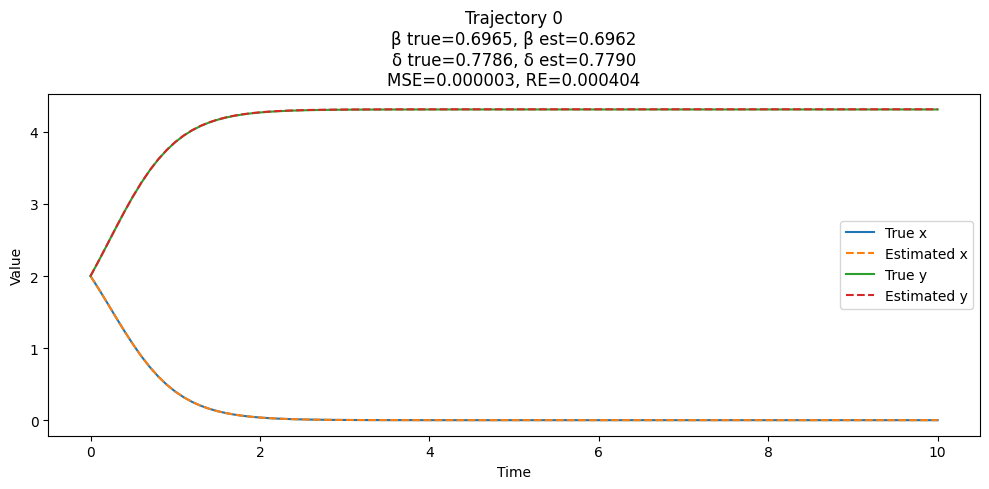

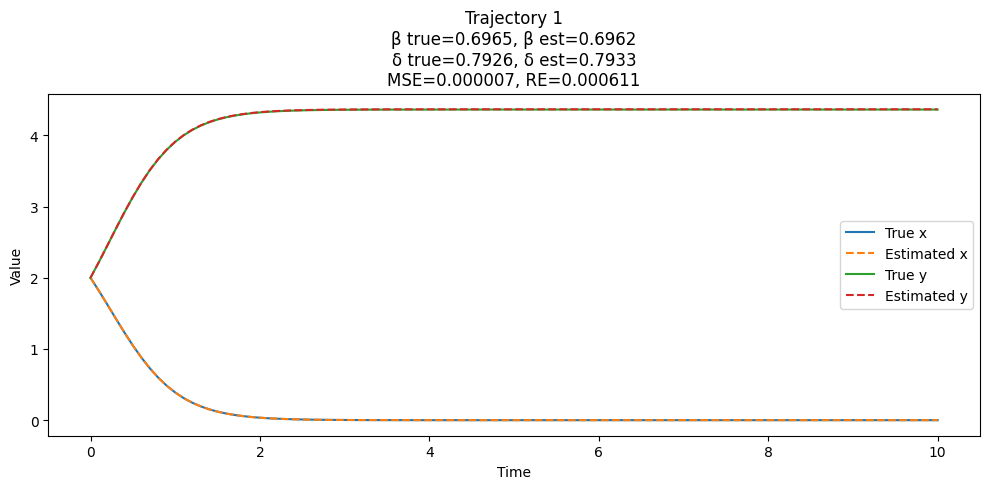

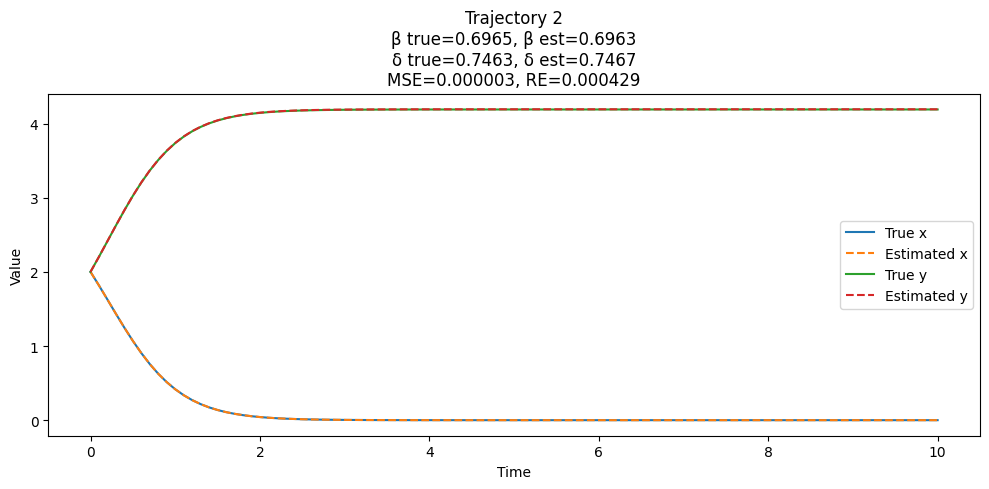

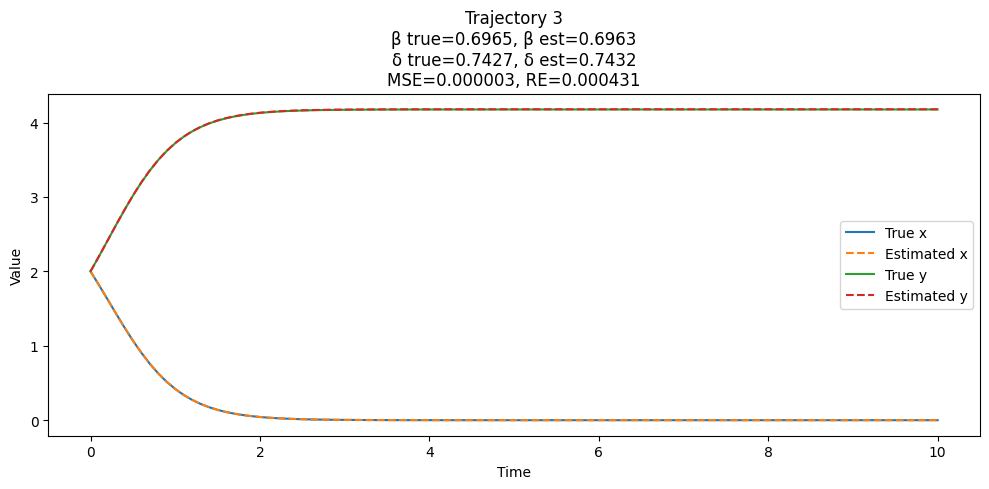

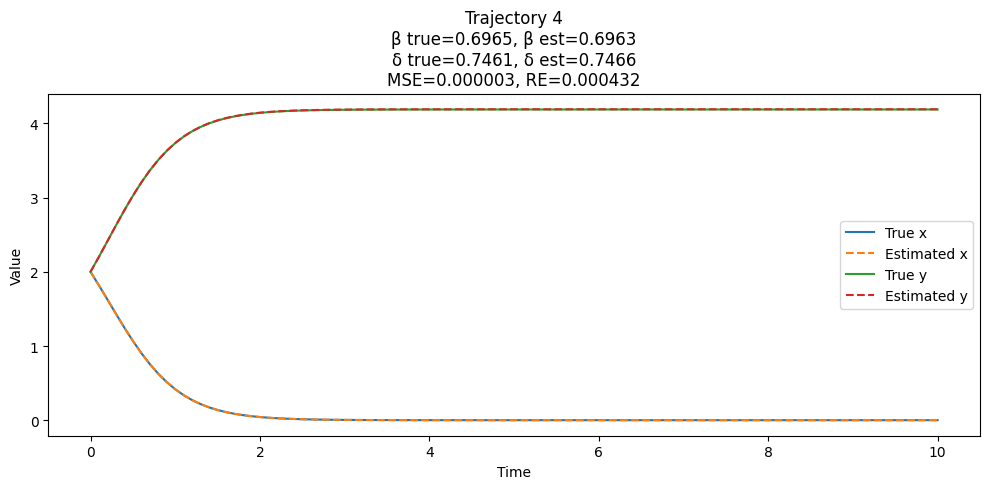

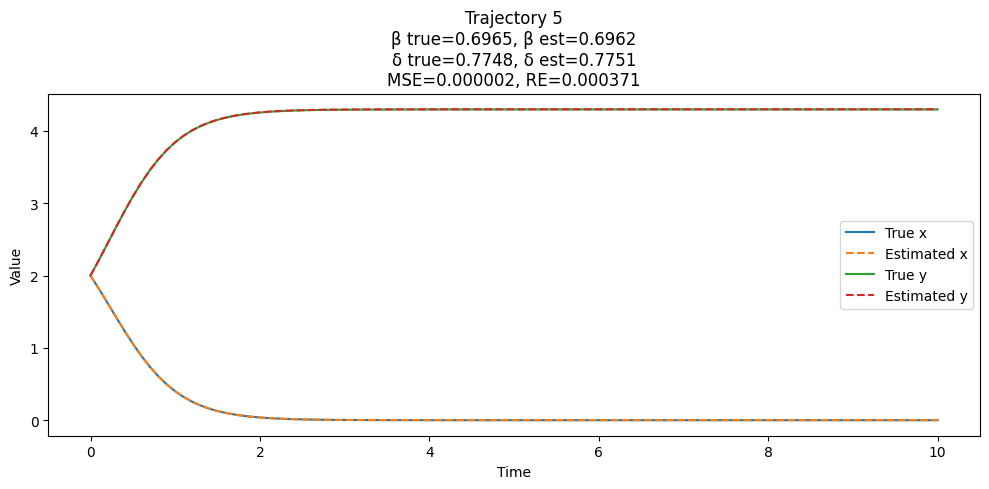

The average MSE value is  3.7861743742441033e-06
The average RSE value is  nan
The average RE value is 0.0004872328202286465
The average parameter difference for beta is 0.00011235756294454613
The average parameter difference for delta is 0.0006892886074047999
The median parameter difference for beta is 9.128502996030852e-05
The median parameter difference for delta is 0.0006714837817514696


/usr/local/lib/python3.12/dist-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/usr/local/lib/python3.12/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [25]:
#Find the MSE of adaptation
pers_beta_array=[]
pers_delta_array=[]
MSE_values=[]
RSE_values=[]
RE_values=[]
PE_values_beta=[]
PE_values_delta=[]

pers_c_difference_array=[]
count=0
max_plots=6

for i in range(len(beta_values_adapt)): #loop through each beta_value in adaptation
    for j in range(len(delta_values_adapt)): #loop through each delta_value in adaptation
      for k in range(num_init_cond_adapt): #loop through each initial condition
            x0=x_init_values_adapt[k]
            y0=y_init_values_adapt[k]

            params=[0,alpha,0,0,-beta_values_adapt[i],0,0,-gamma,0,0,delta_values_adapt[j],0] #true parameters of the Lotka_Volterra
            results=odeint(SINDY_model,np.array([x0,y0]),t_test,args=(params,)) #generate the true trajectories

            #separate into x and y values
            x_values_adapt=results[:,0] #x_values of traj
            y_values_adapt=results[:,1] #y-values of traj




            beta_est=recovered_beta_common+init_guess_pers[count] #our estimated beta; equal to beta_c_i (from training) + beta_p (from adaptation)
            delta_est=recovered_delta_common+init_guess_pers[len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt+count]
            pars=[0,alpha,0,0,-beta_est,0,0,-gamma,0,0,delta_est,0]
            results_hat=odeint(SINDY_model,np.array([x0,y0]),t_test,args=(pars,)) #generate new traj using the estimated betas and deltas
            #print("Betas", beta_values_adapt[i],beta_est)

            #print("Deltas", delta_values_adapt[j],delta_est)


            pd_beta=np.abs(beta_values_adapt[i]-beta_est)
            pd_delta=np.abs(delta_values_adapt[j]-delta_est)
            MSE = np.square(np.subtract(results,results_hat)).mean()
            RE=math.sqrt(len(t)*MSE)/(np.linalg.norm(results))


            #RSE=MSE/np.linalg.norm(results)
            # print("The MSE for trajectory ", count, "is", MSE)
            # print("The RSE for trajectory ", count, "is", RSE)
            # print()


            MSE_values=np.append(MSE_values,MSE)
            #RSE_values=np.append(RSE_values,RSE)
            RE_values=np.append(RE_values,RE)
            PE_values_beta=np.append(PE_values_beta,pd_beta)
            PE_values_delta=np.append(PE_values_delta,pd_delta)
            if count < max_plots:

                plt.figure(figsize=(10, 5))

                # x trajectories
                plt.plot(t_test, x_values_adapt,
                         label='True x')

                plt.plot(t_test, results_hat[:, 0], '--',
                         label='Estimated x')

                # y trajectories
                plt.plot(t_test, y_values_adapt,
                         label='True y')

                plt.plot(t_test, results_hat[:, 1], '--',
                         label='Estimated y')

                plt.xlabel('Time')
                plt.ylabel('Value')

                plt.title(
                    f'Trajectory {count}\n'
                    f'β true={beta_values_adapt[i]:.4f}, β est={beta_est:.4f}\n'
                    f'δ true={delta_values_adapt[j]:.4f}, δ est={delta_est:.4f}\n'
                    f'MSE={MSE:.6f}, RE={RE:.6f}'
                )

                plt.legend()
                plt.tight_layout()

                # Save each plot as its own PDF
                plt.savefig(f"trajectory_{count}.pdf", format='pdf')

                plt.show()
                plt.close()




            # pers_beta_array=np.append(pers_beta_array,init_guess_pers[count])
            # pers_delta_array=np.append(pers_delta_array,init_guess_pers[len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt+count])
            count+=1

#personalized components
# print("Est personalized beta", pers_beta_array)
# print("Est personalized delta", pers_delta_array)

#the MSE and RSE for adaptation
MSE_average=np.average(MSE_values)
RSE_average=np.average(RSE_values)
RE_average=np.average(RE_values)
PE_beta_average=np.average(PE_values_beta)
PE_delta_average=np.average(PE_values_delta)
PE_beta_median=np.median(PE_values_beta)
PE_delta_median=np.median(PE_values_delta)
print("The average MSE value is " , MSE_average)
print("The average RSE value is " , RSE_average)
print("The average RE value is", RE_average)
print("The average parameter difference for beta is",PE_beta_average)
print("The average parameter difference for delta is", PE_delta_average)
print("The median parameter difference for beta is", PE_beta_median)
print("The median parameter difference for delta is", PE_delta_median)
# print("PE values beta: ",PE_values_beta)
# print("PE values delta: ", PE_values_delta)

In [26]:
# #initialize empty arrays
# pers_beta_true_array=np.array([])
# pers_beta_difference_array=np.array([])
# pers_delta_true_array=np.array([])
# pers_delta_difference_array=np.array([])

# MSE_values=np.array([])
# RSE_values=np.array([])

# #recovered_beta_common=init_guess[0] #the recovered common component
# #recovered_delta_common=init_guess[1]  #the recovered personalized components for each trajectory

# recovered_beta_pers=init_guess_pers[0:len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt] #array containing the personalized beta for each traj.
# recovered_delta_pers=init_guess_pers[len(beta_values_adapt)*len(delta_values_adapt)*num_init_cond_adapt:] #array containing the personalized delta for each traj.

# print(recovered_beta_pers)
# print(recovered_delta_pers)

# #print(recovered_common)
# #print(recovered_pers)
# #print(recovered_pers.shape)
# count=0
# for i in range(len(beta_values_adapt)): #loop through each beta_value
#     for j in range(len(delta_values_adapt)): #loop through each delta_value
#       for k in range(num_init_cond_adapt): #loop through each initial condition
#            #you're looping thru each trajectory; there are len(beta_values)*len(delta_values)*num_init_cond total trajectories
#             beta_est=recovered_beta_common[0]+recovered_beta_pers[count] #the estimated beta value: beta_est=beta_common_est+beta_pers_est
#             delta_est=recovered_delta_common[0]+recovered_delta_pers[count] #the estimated delta value: delta_est=delta_common_est+delta_pers_est
#             print(beta_est)
#             print(delta_est)
#             params=[0,alpha,0,0,-beta_values_adapt[i],0,0,-gamma,0,0,delta_values_adapt[j],0] #true parameters
#             params2=[0,alpha,0,0,-beta_est,0,0,-gamma,0,0,delta_est,0] #parameters w recovered c_value
#             #print("sum is", i+j+k)

#             x0=x_init_values_adapt[k] #initial condition
#             y0=y_init_values_adapt[k]
#             # t = np.linspace(0, 20, 100)
#             #results_i = odeint(logistic_growth_controlled, La_o , t, args=(params, treatment_function, cycles)) #trajectory generated using the true c values
#             #results_hat_i=odeint(logistic_growth_controlled,La_o,t,args=(params2,treatment_function,cycles))    #trajectory generated using the recovered c values

#             results_i=odeint(SINDY_model,np.array([x0,y0]),t,args=(params,)) #true trajectory
#             results_hat_i=odeint(SINDY_model,np.array([x0,y0]),t,args=(params2,)) #trajectory with estimated value for c

#             plt.plot(t, results_i[:,0], label='x')
#             plt.plot(t, results_i[:,1], label='y')
#             plt.plot(t, results_hat_i[:,0], label='x_hat')
#             plt.plot(t, results_hat_i[:,1], label='Y_hat')
#             plt.yscale('linear')
#             plt.legend()
#             plt.show()

#             MSE = np.square(np.subtract(results_i,results_hat_i)).mean() #MSE
#             RSE=MSE/np.linalg.norm(results_i) #MSE divided by the 2-norm of the true value
#             #print("The MSE is ", MSE)
#             #print("The RSE is ", RSE)

#             MSE_values=np.append(MSE_values,MSE)
#             RSE_values=np.append(RSE_values,RSE)

#             count+=1


#             #pers_c_true=c_values[i]-true_c_common #the "true" personalized component c_(p_i) (c_p_i=c_i-c_c)
#             #pers_c_true_array=np.append(pers_c_true_array,pers_c_true) #add to an array

#             #pers_c_true_difference=pers_c_true-recovered_pers[i] #the difference between the true and recovered personalized components
#             #pers_c_difference_array=np.append(pers_c_difference_array,pers_c_true_difference)

# #print("The true common component is ", true_c_common)
# #print("The recovered common component is ", recovered_common)
# #print("Difference in common components", true_c_common-recovered_common)

# #print("True personalized comp", pers_c_true_array)
# #print("Est personalized comp", recovered_pers)
# #print("Difference in personalized components", pers_c_difference_array)



# MSE_average=np.average(MSE_values) #find the average MSE of all trajectories
# RSE_average=np.average(RSE_values) #find the average RSE for all trajectories
# print("The average MSE value is " , MSE_average)
# print("The average RSE value is " , RSE_average)